<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Hospital_Beds_Management_Dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d jaderz/hospital-beds-management

# Unziping the downloaded file
!unzip hospital-beds-management.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/jaderz/hospital-beds-management
License(s): CC0-1.0
hospital-beds-management.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  hospital-beds-management.zip
  inflating: patients.csv            
  inflating: services_weekly.csv     
  inflating: staff.csv               
  inflating: staff_schedule.csv      


In [17]:
df = pd.read_csv('services_weekly.csv')
df.head(11)

,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
0,1,1,emergency,32,76,32,44,67,70,none
1,1,1,surgery,45,130,45,85,83,78,flu
2,1,1,general_medicine,37,201,37,164,97,43,flu
3,1,1,ICU,22,31,22,9,84,91,flu
4,2,1,emergency,28,169,28,141,75,64,none
5,2,1,surgery,40,26,26,0,96,56,none
6,2,1,general_medicine,43,183,43,140,73,93,flu
7,2,1,ICU,16,7,7,0,79,85,donation
8,3,1,emergency,32,177,32,145,73,58,flu
9,3,1,surgery,27,66,27,39,63,72,flu


In [18]:
df.tail(11)

,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
197,50,12,surgery,59,65,59,6,95,85,none
198,50,12,general_medicine,72,57,57,0,79,60,none
199,50,12,ICU,22,13,13,0,65,57,none
200,51,12,emergency,31,123,31,92,71,75,none
201,51,12,surgery,63,48,48,0,84,82,none
202,51,12,general_medicine,74,285,74,211,95,89,flu
203,51,12,ICU,18,15,15,0,87,80,none
204,52,12,emergency,26,130,26,104,88,63,none
205,52,12,surgery,53,39,39,0,82,50,none
206,52,12,general_medicine,65,225,65,160,82,40,flu


In [19]:
df.shape

(208, 10)

In [20]:
df.columns

Index(['week', 'month', 'service', 'available_beds', 'patients_request',
       'patients_admitted', 'patients_refused', 'patient_satisfaction',
       'staff_morale', 'event'],
      dtype='object')

In [21]:
df.dtypes

,0
week,int64
month,int64
service,object
available_beds,int64
patients_request,int64
patients_admitted,int64
patients_refused,int64
patient_satisfaction,int64
staff_morale,int64
event,object


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   week                  208 non-null    int64 
 1   month                 208 non-null    int64 
 2   service               208 non-null    object
 3   available_beds        208 non-null    int64 
 4   patients_request      208 non-null    int64 
 5   patients_admitted     208 non-null    int64 
 6   patients_refused      208 non-null    int64 
 7   patient_satisfaction  208 non-null    int64 
 8   staff_morale          208 non-null    int64 
 9   event                 208 non-null    object
dtypes: int64(8), object(2)
memory usage: 16.4+ KB


In [23]:
df.describe(include = 'all')

,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
count,208.000000,208.000000,208,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,emergency,NaN,NaN,NaN,NaN,NaN,NaN,none
freq,NaN,NaN,52,NaN,NaN,NaN,NaN,NaN,NaN,164
mean,26.500000,6.923077,NaN,30.346154,64.870192,28.129808,36.740385,80.000000,72.567308,NaN
std,15.044539,3.634755,NaN,15.172929,58.738572,14.676791,55.015763,11.125546,15.457759,NaN
min,1.000000,1.000000,NaN,8.000000,5.000000,5.000000,0.000000,60.000000,31.000000,NaN
25%,13.750000,4.000000,NaN,18.000000,23.750000,16.000000,0.000000,70.000000,60.000000,NaN
50%,26.500000,7.000000,NaN,27.500000,49.000000,26.000000,13.500000,81.000000,73.000000,NaN
75%,39.250000,10.000000,NaN,40.000000,86.000000,37.000000,52.500000,89.000000,86.000000,NaN


In [24]:
df.isnull().sum()

,0
week,0
month,0
service,0
available_beds,0
patients_request,0
patients_admitted,0
patients_refused,0
patient_satisfaction,0
staff_morale,0
event,0


In [25]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

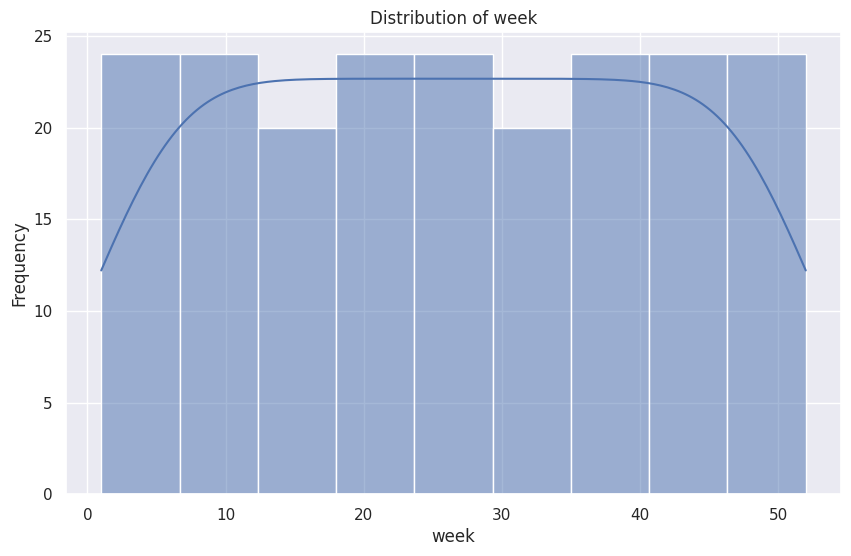

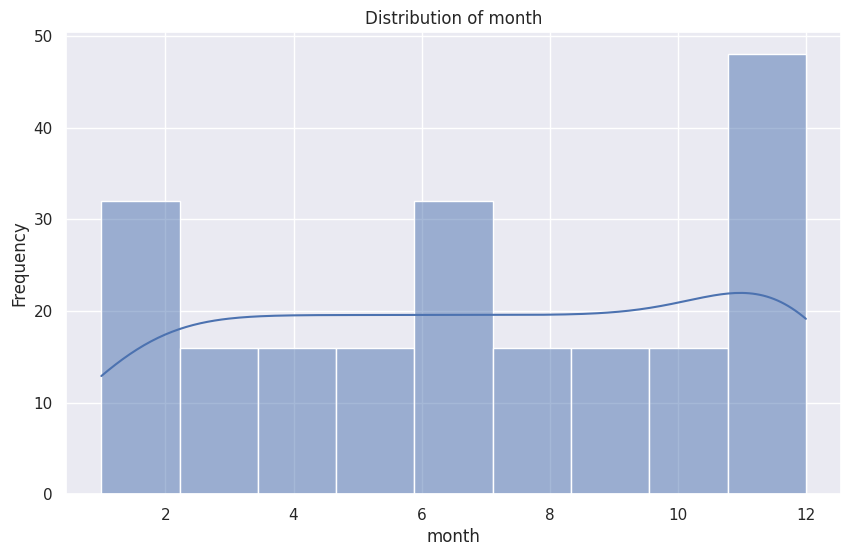

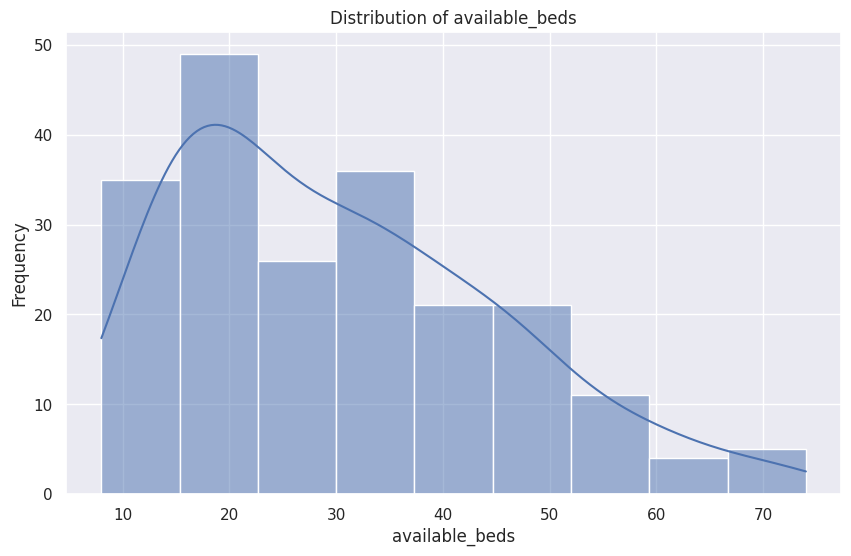

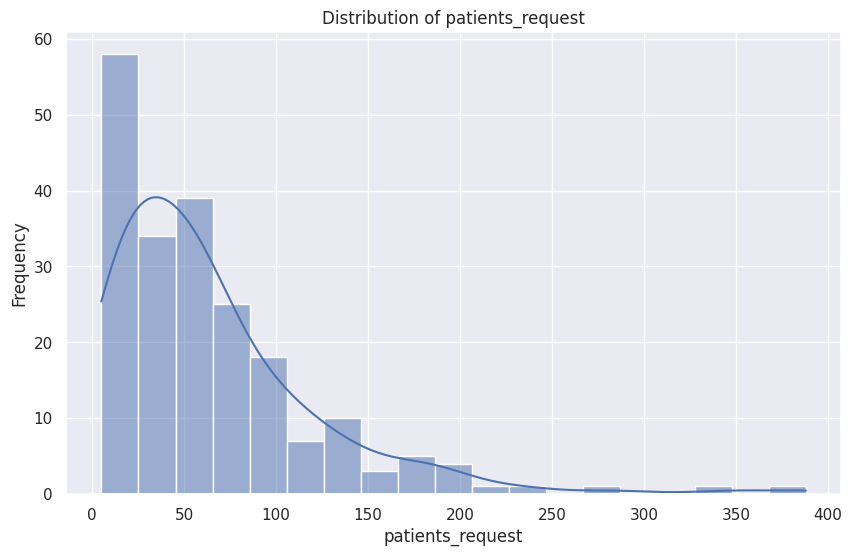

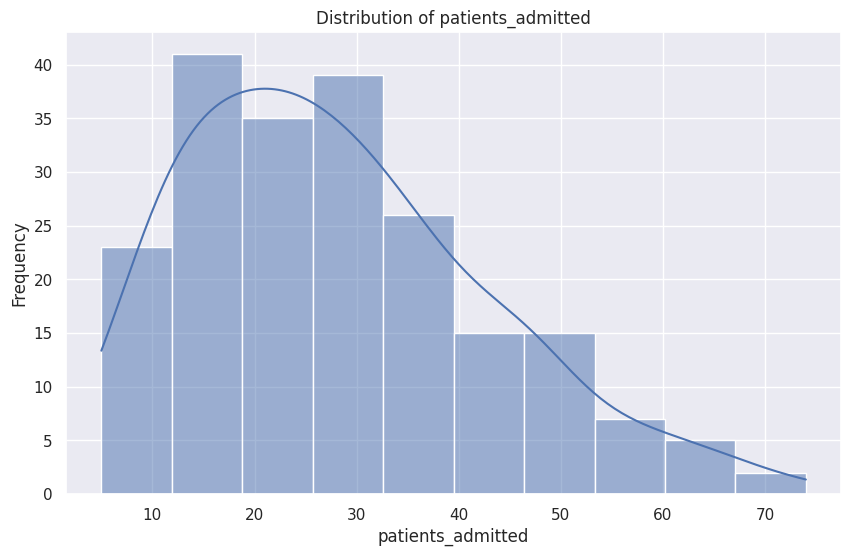

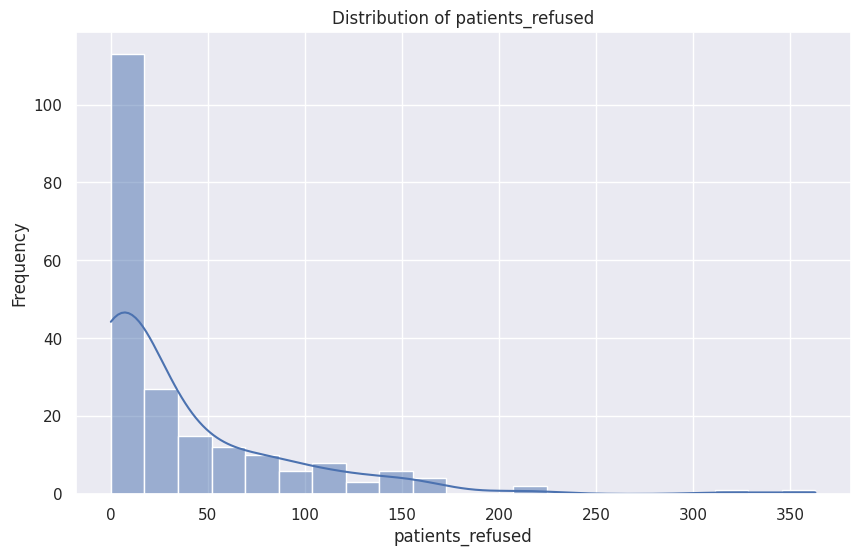

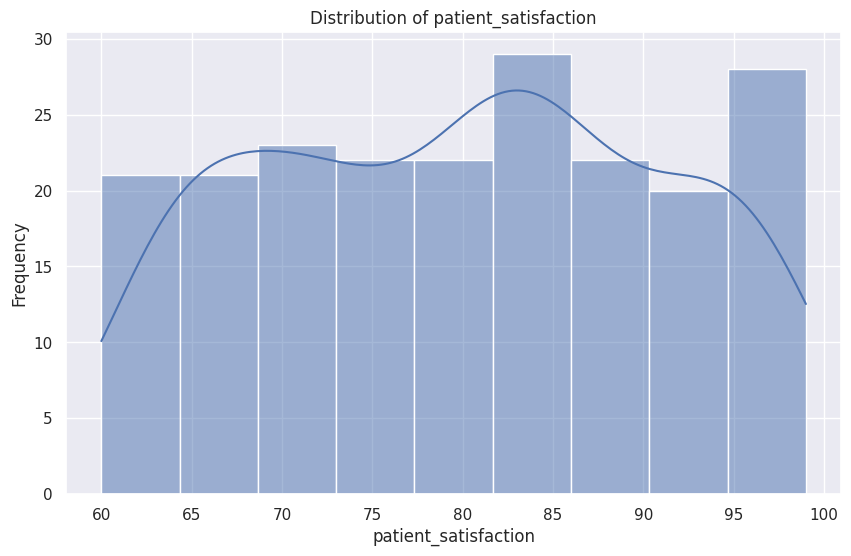

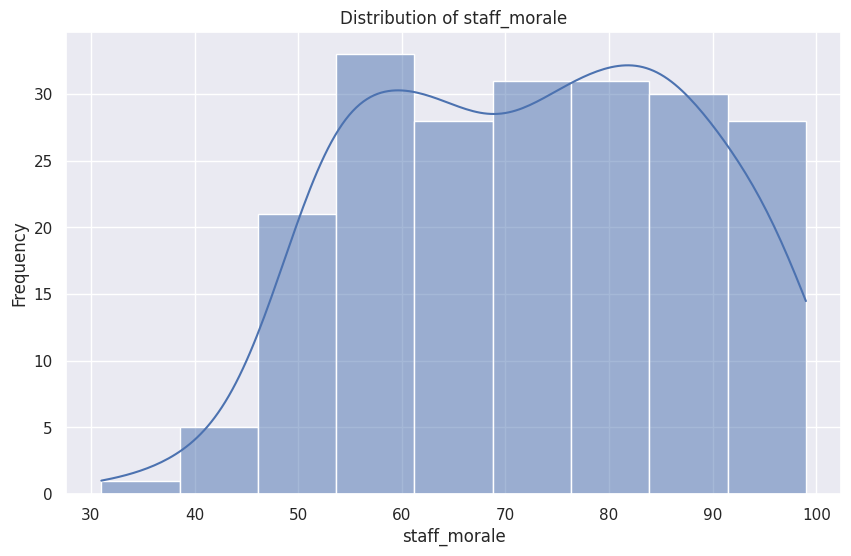

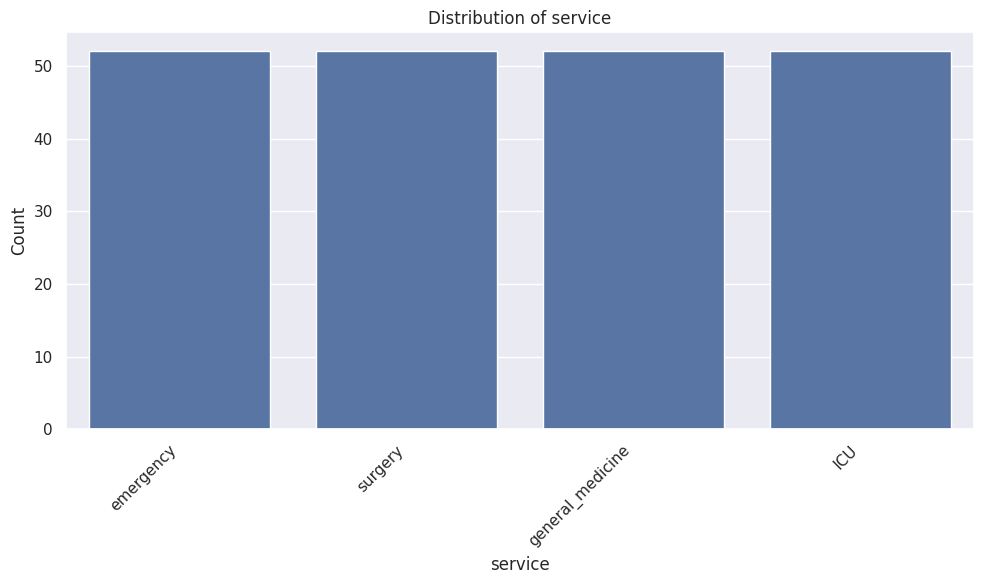

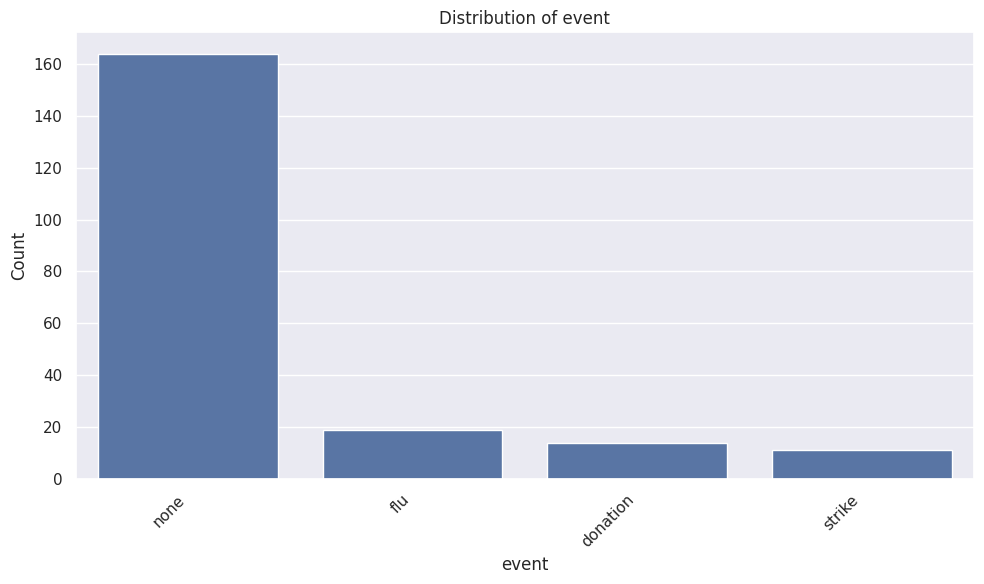

Value counts for service:
service
emergency           52
surgery             52
general_medicine    52
ICU                 52
Name: count, dtype: int64

Value counts for event:
event
none        164
flu          19
donation     14
strike       11
Name: count, dtype: int64



In [26]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

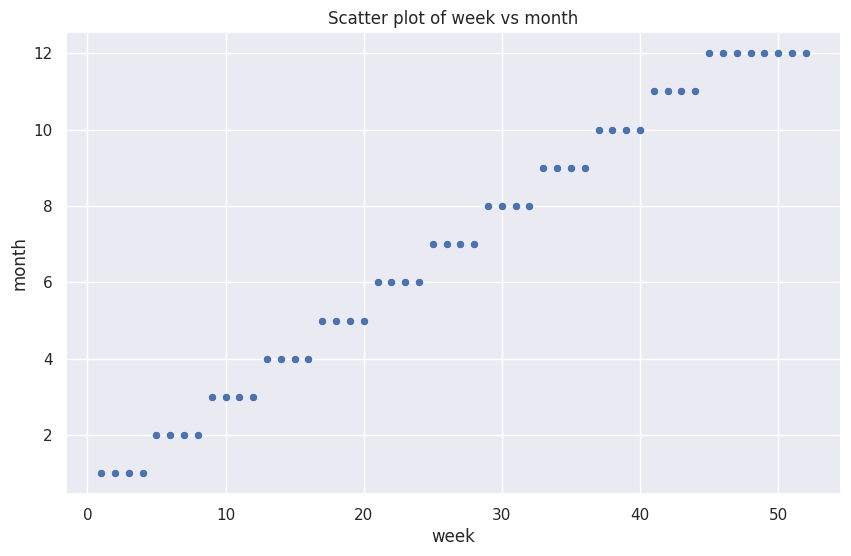

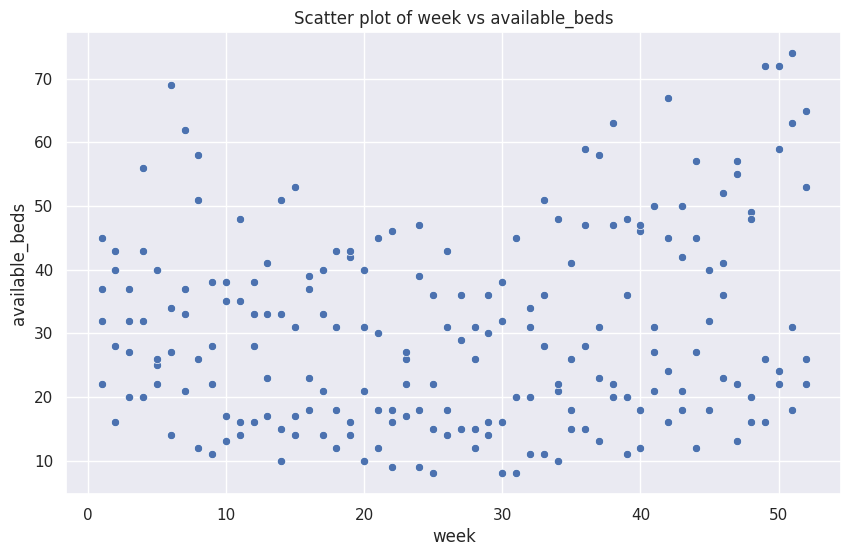

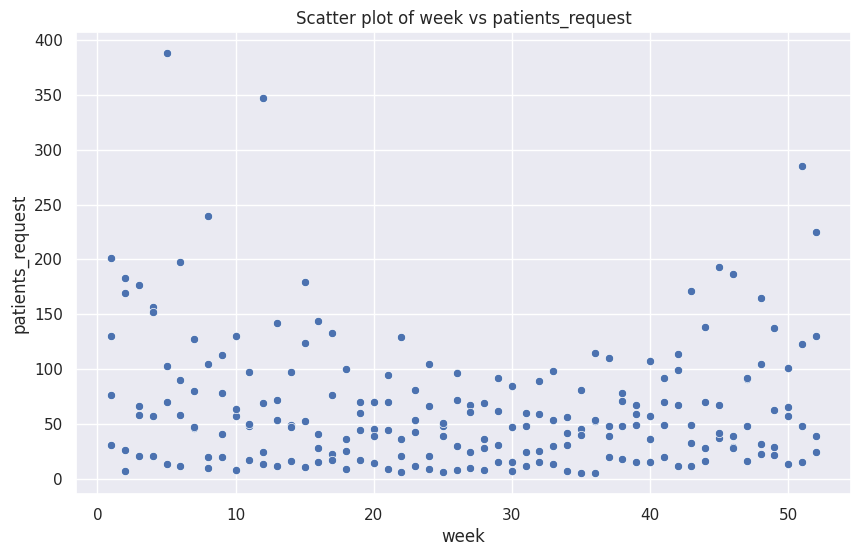

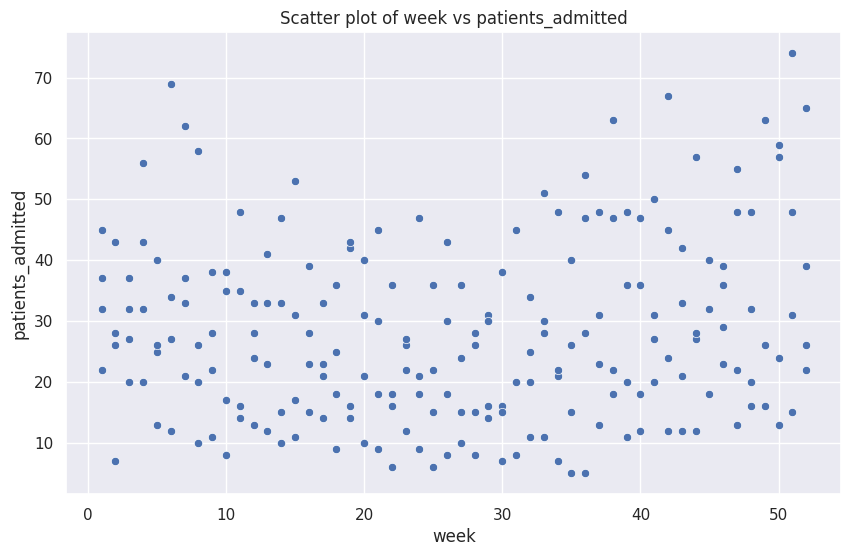

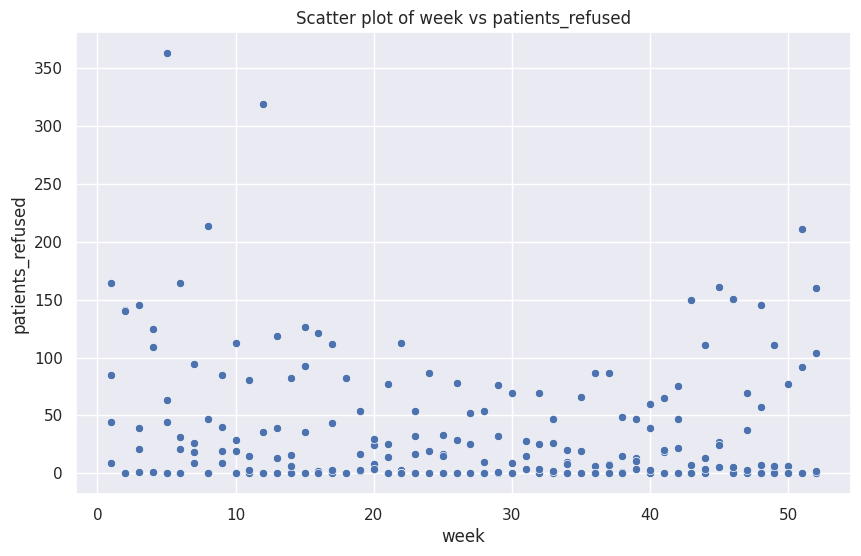

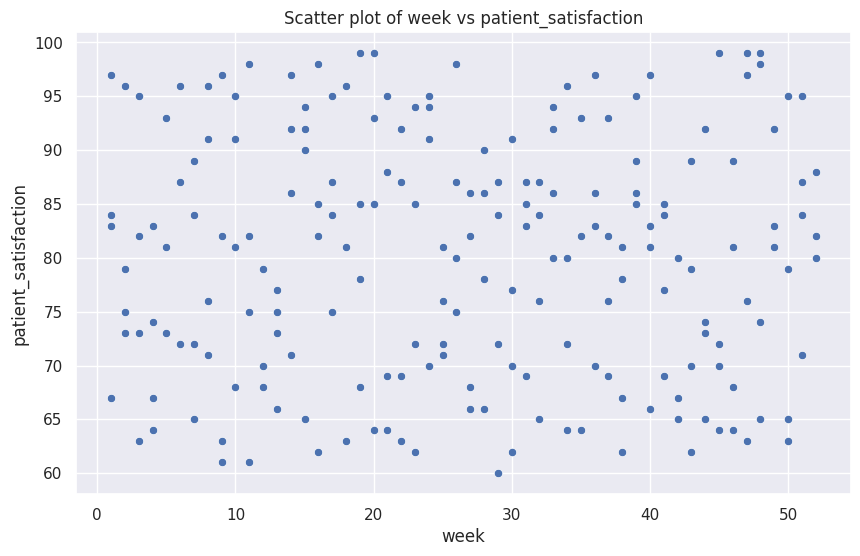

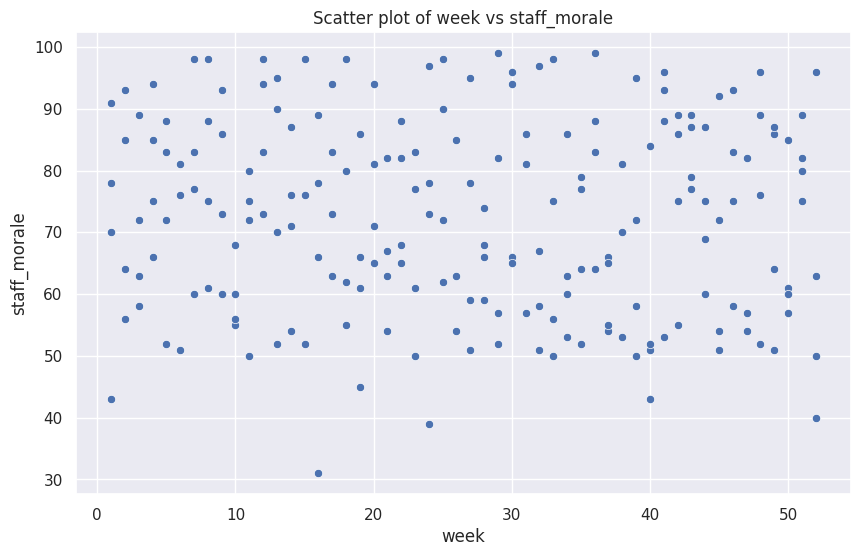

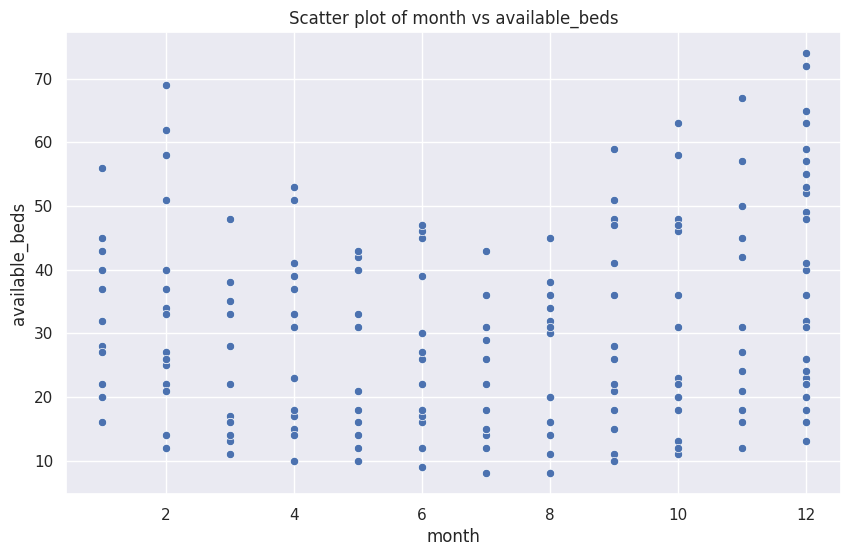

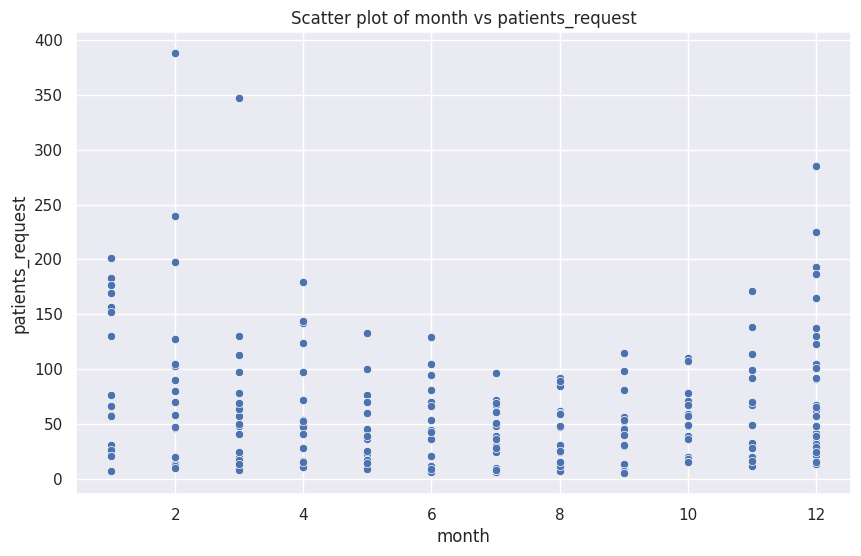

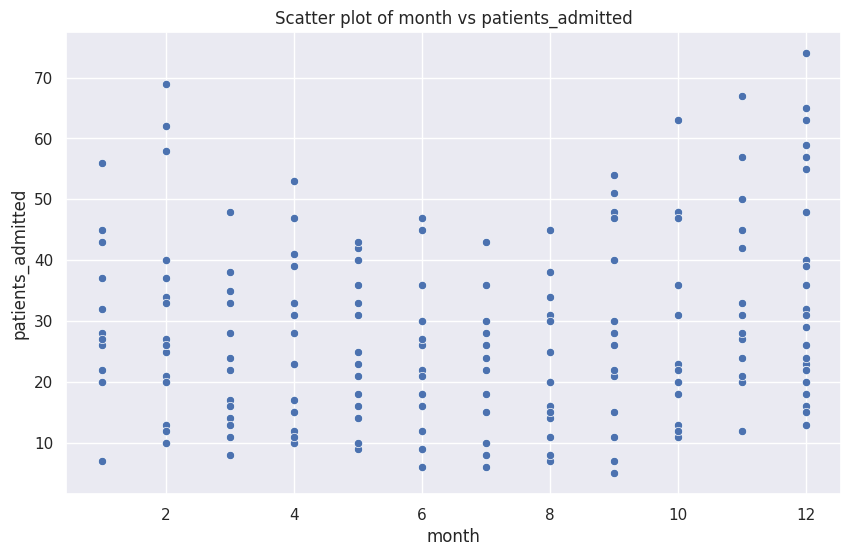

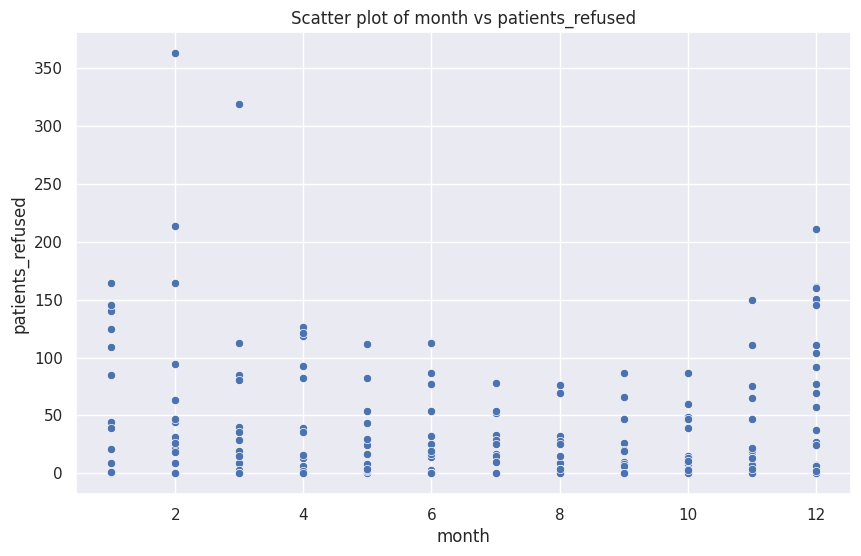

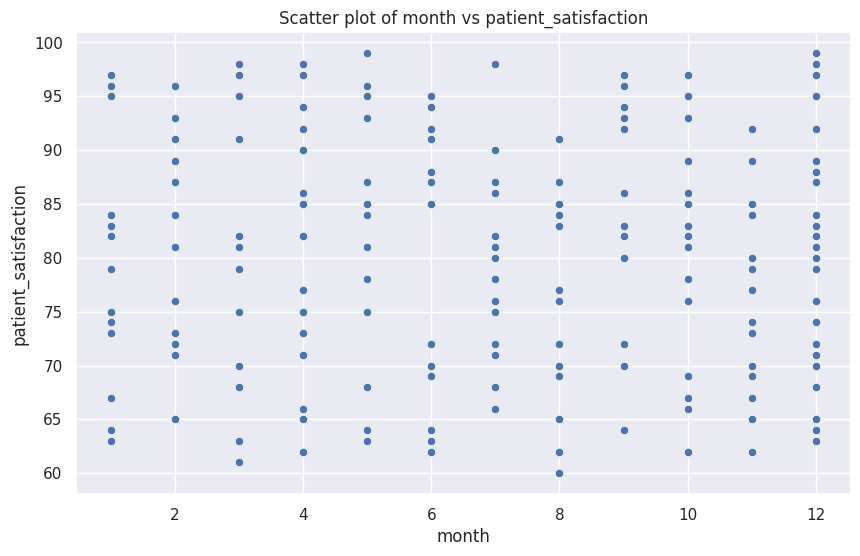

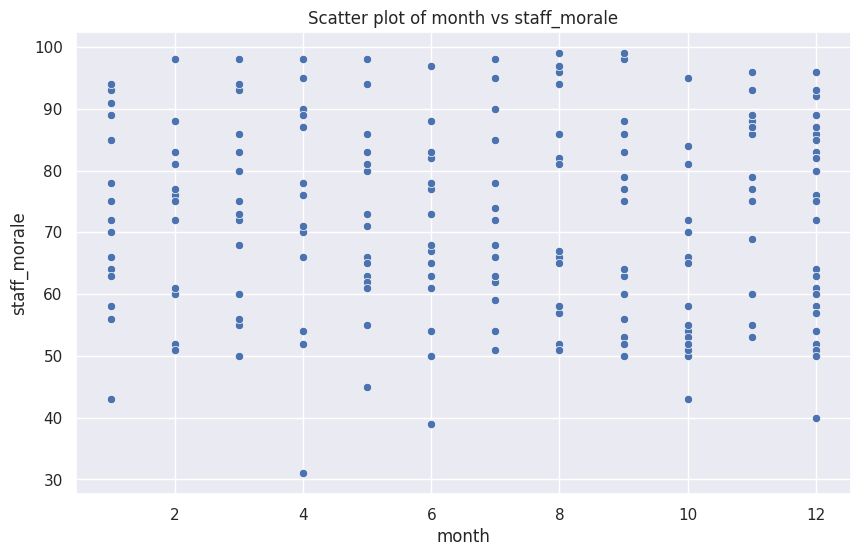

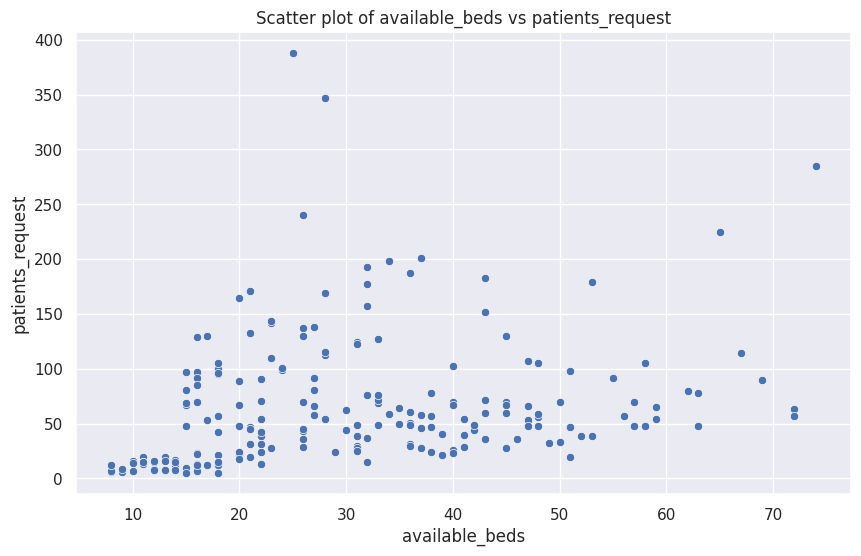

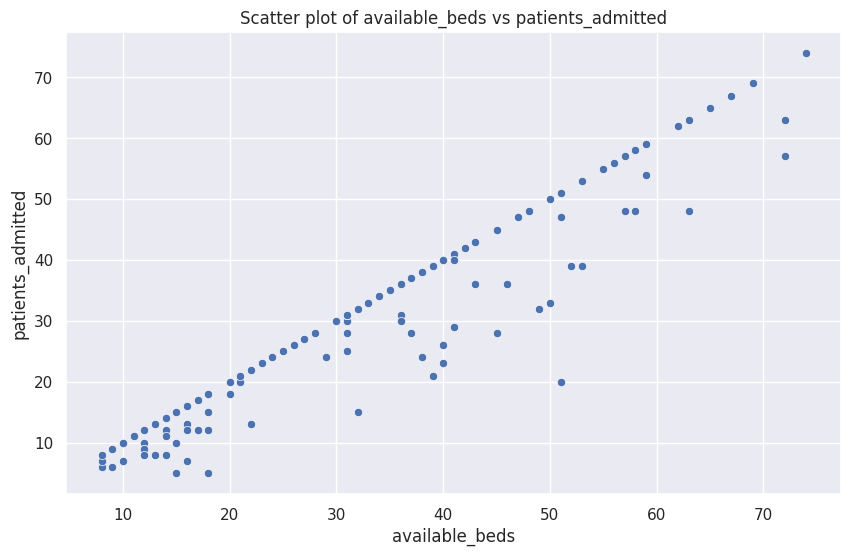

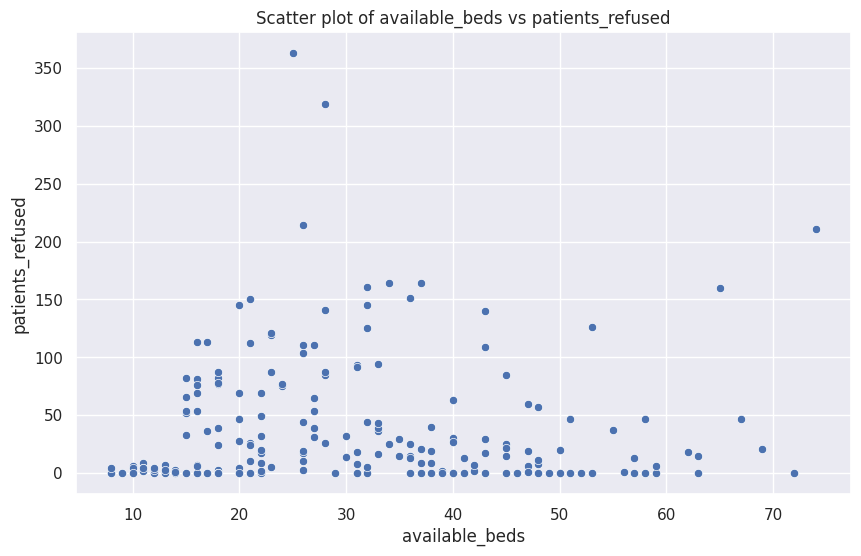

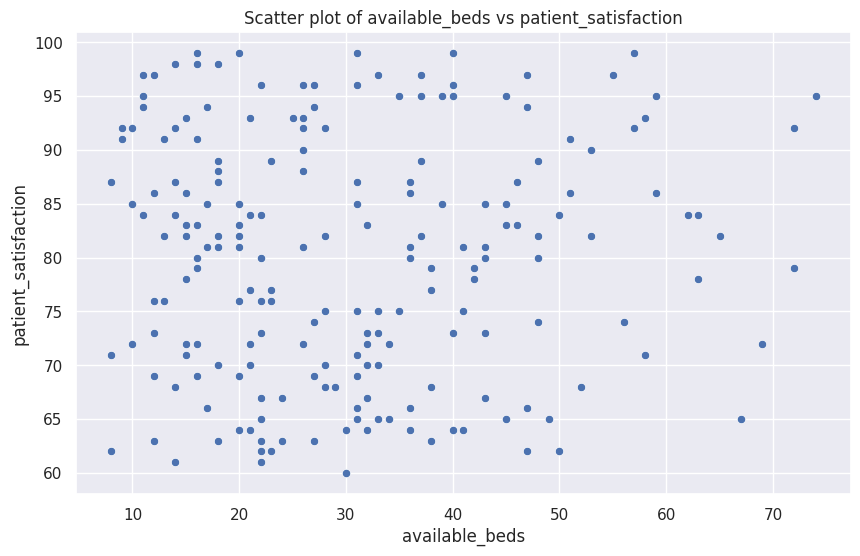

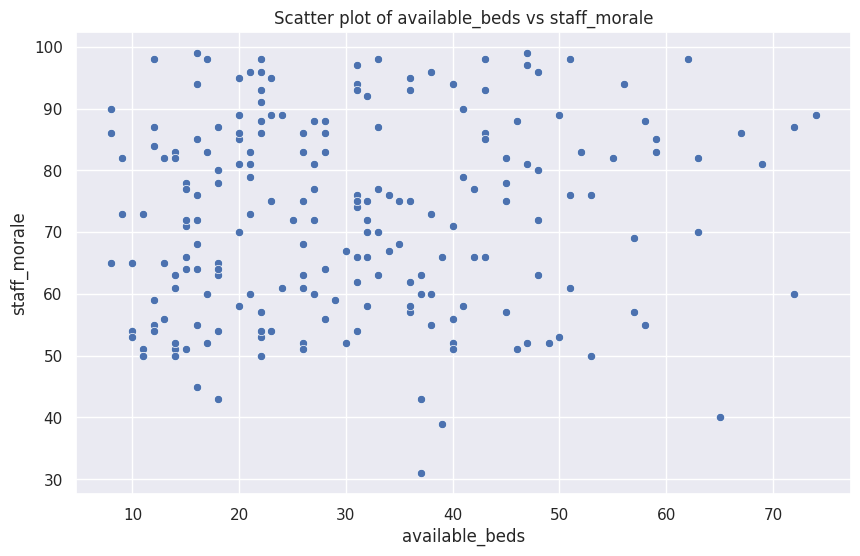

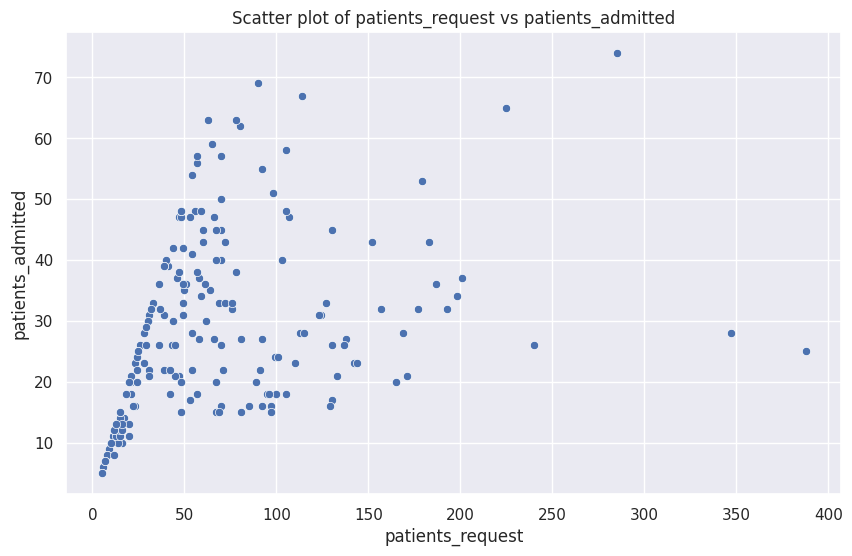

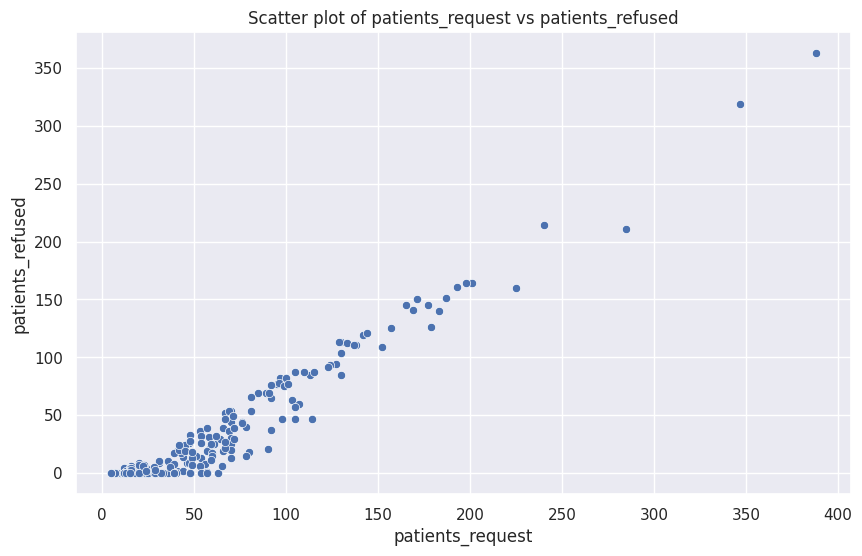

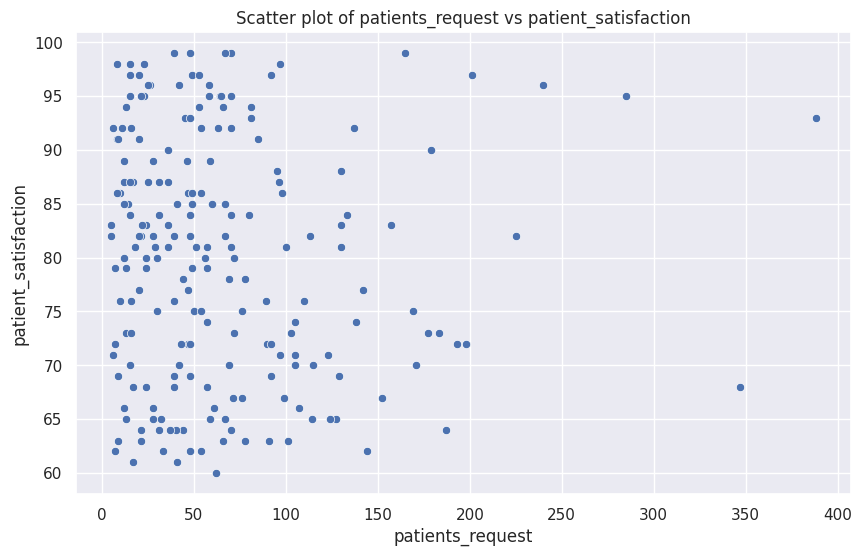

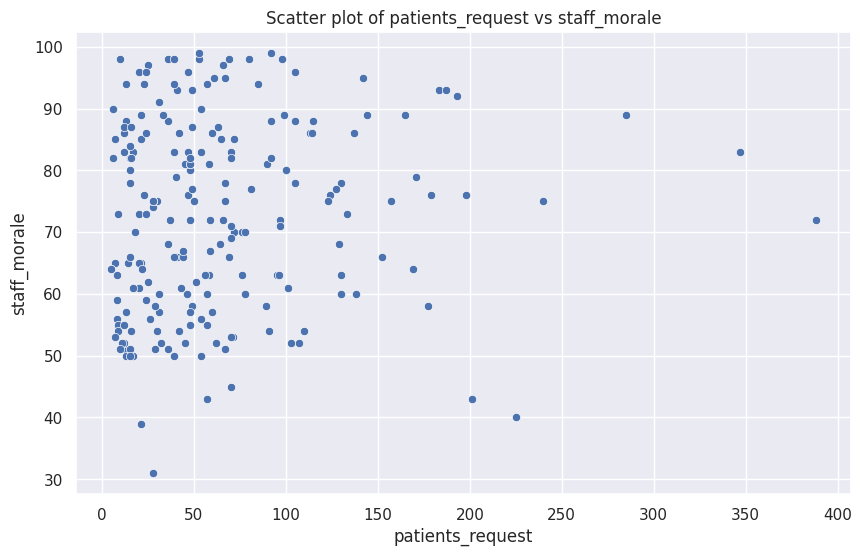

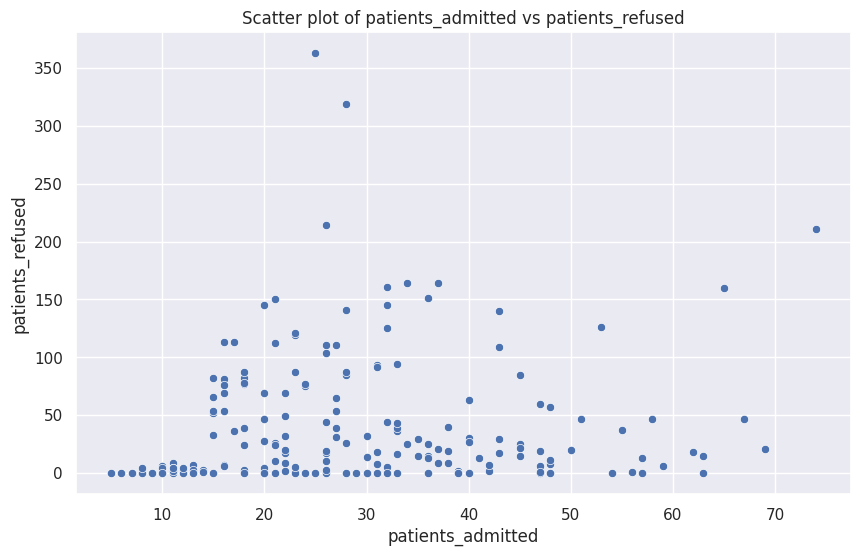

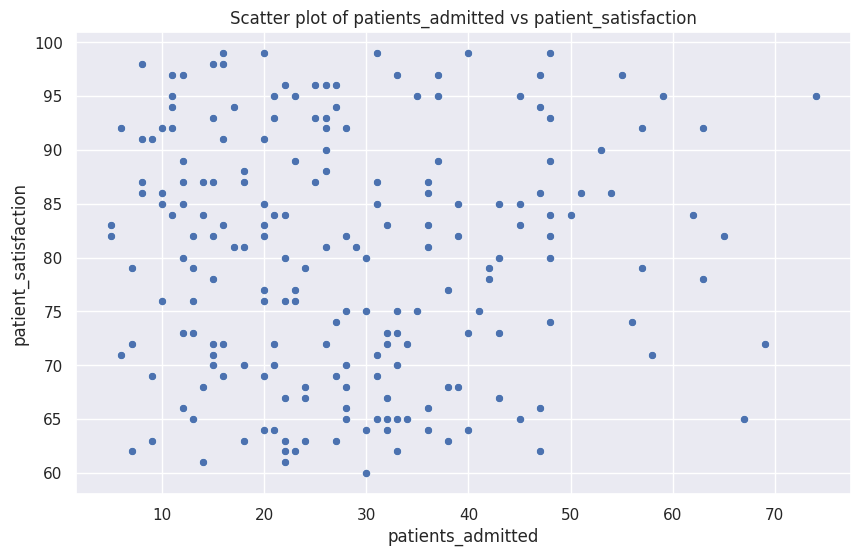

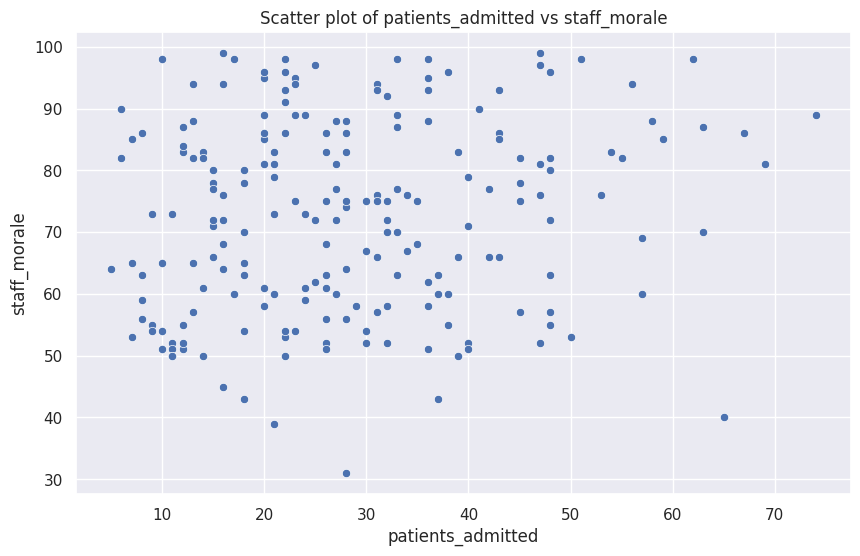

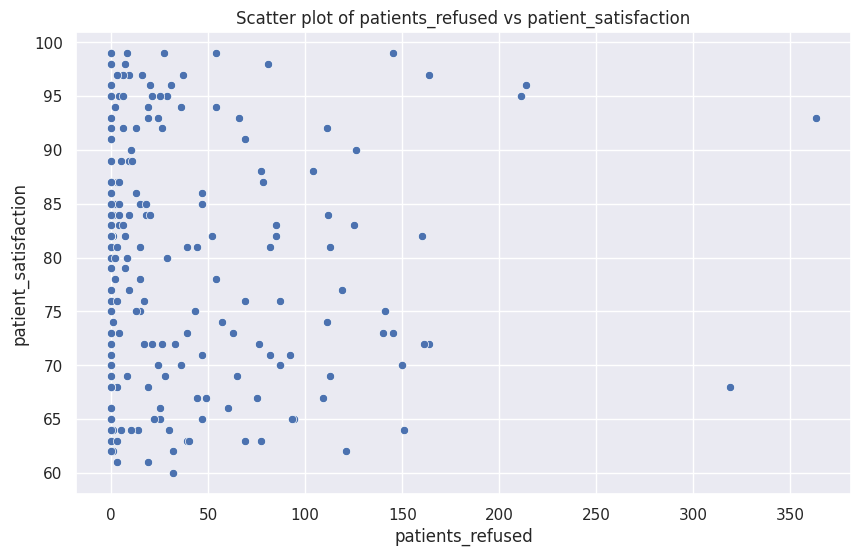

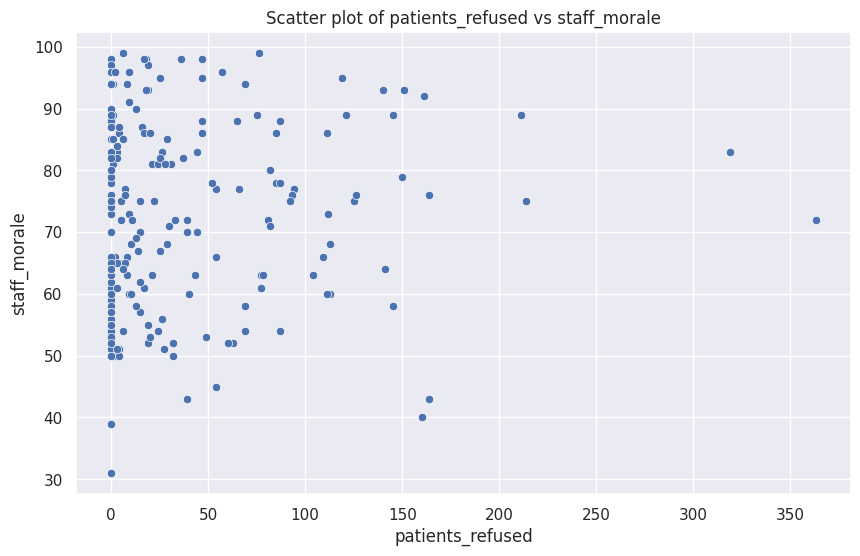

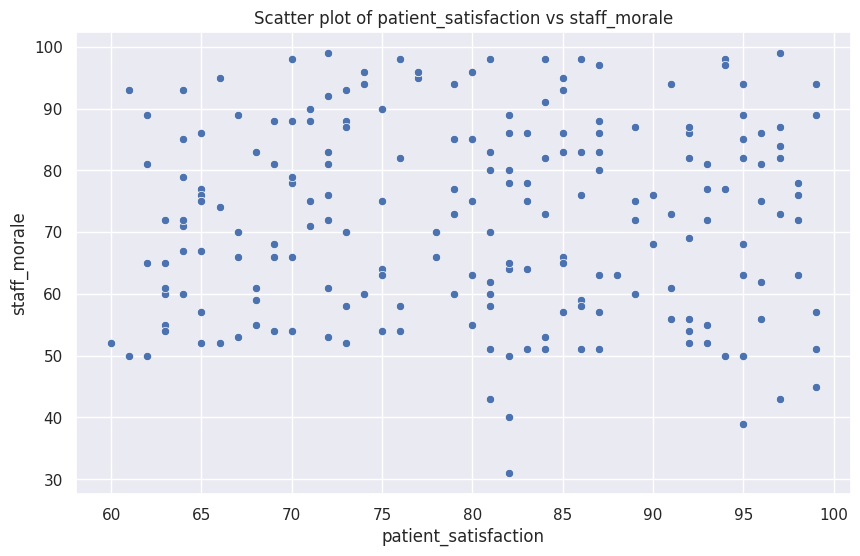

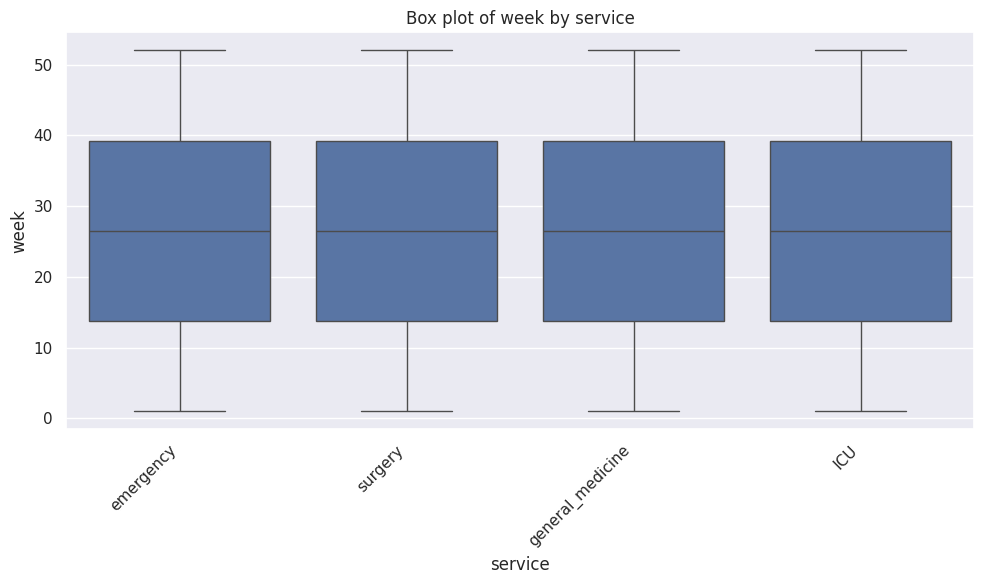

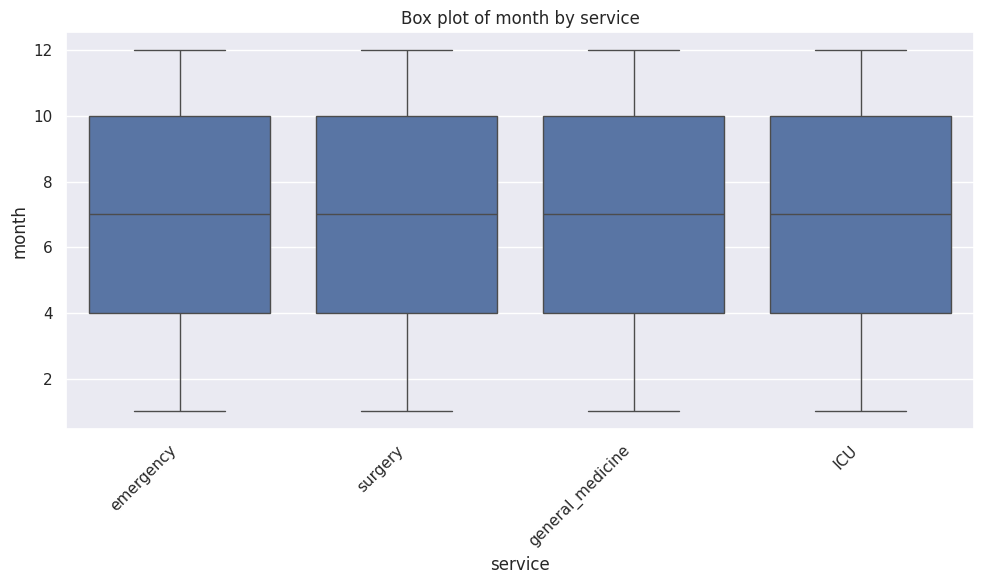

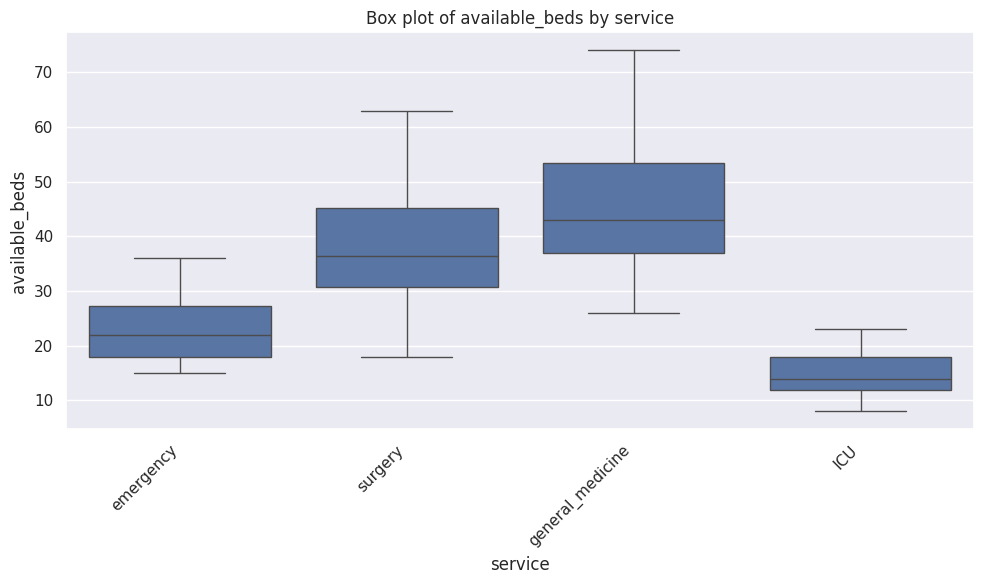

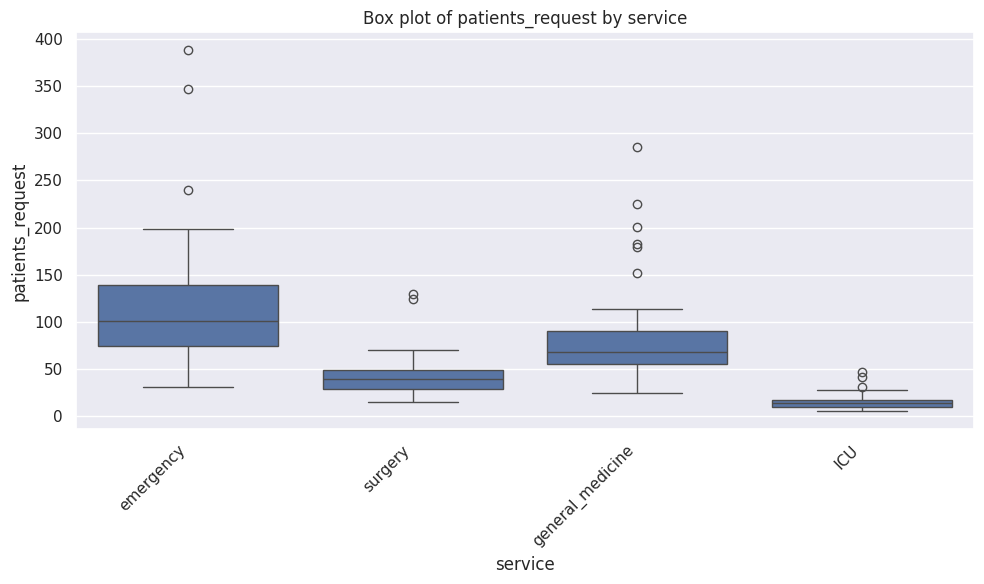

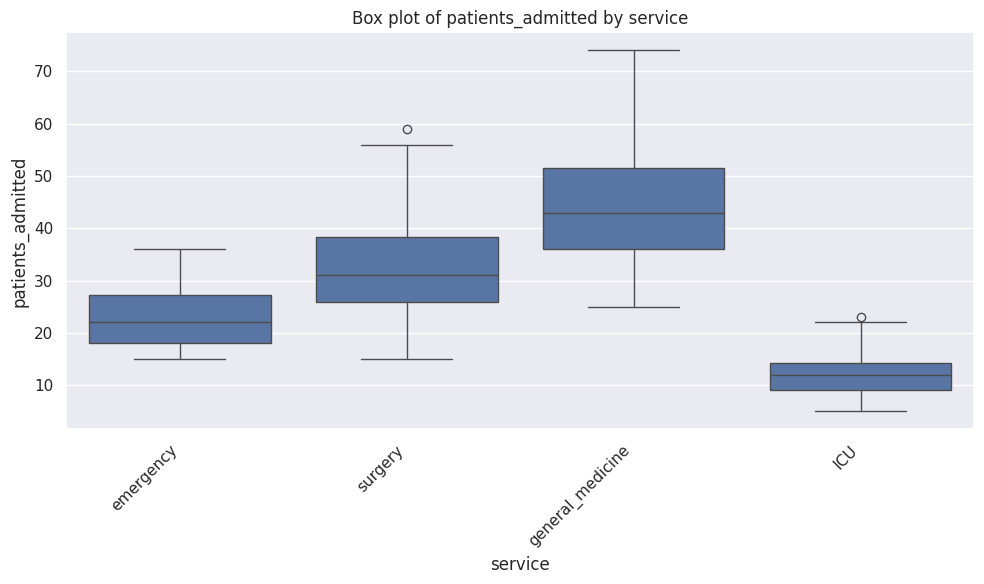

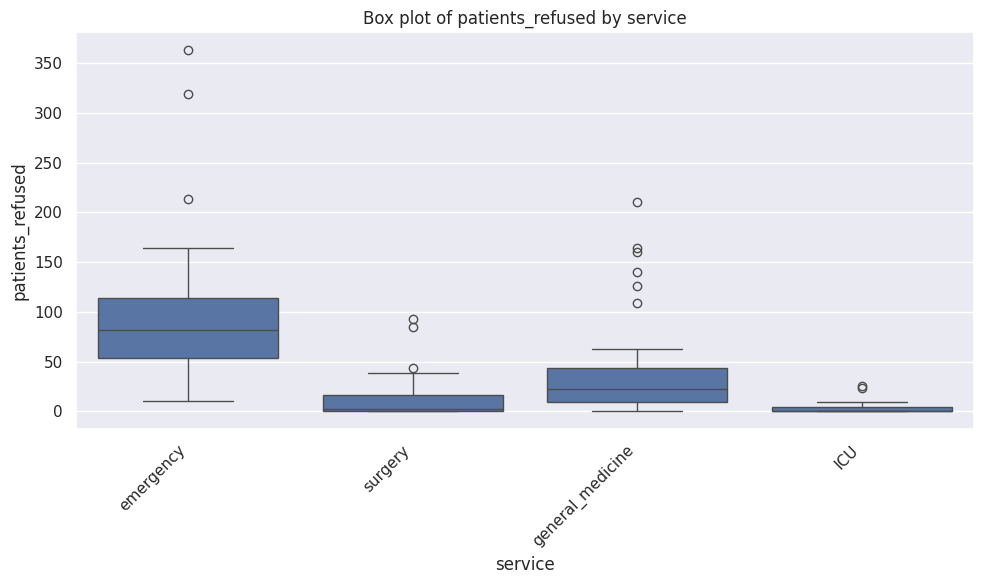

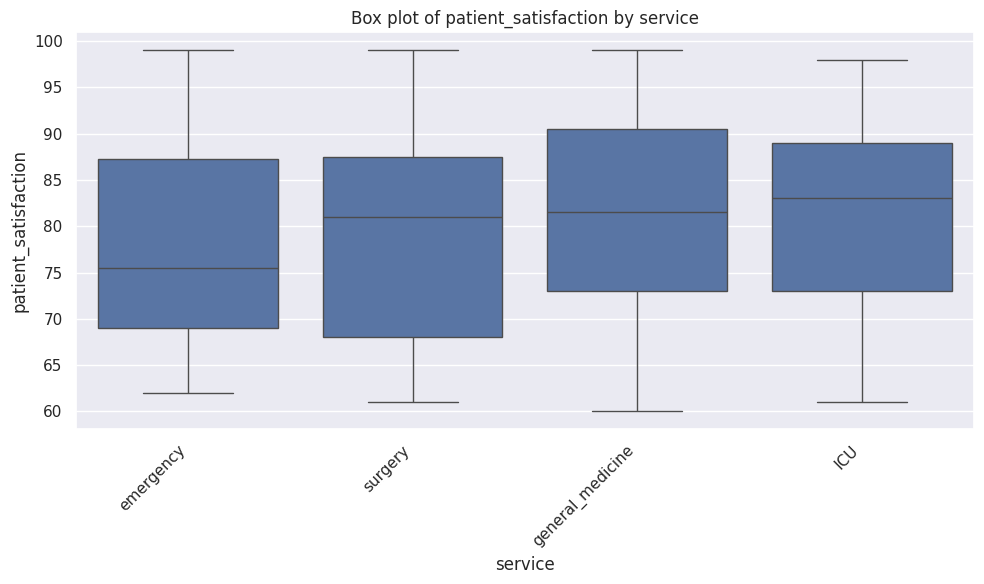

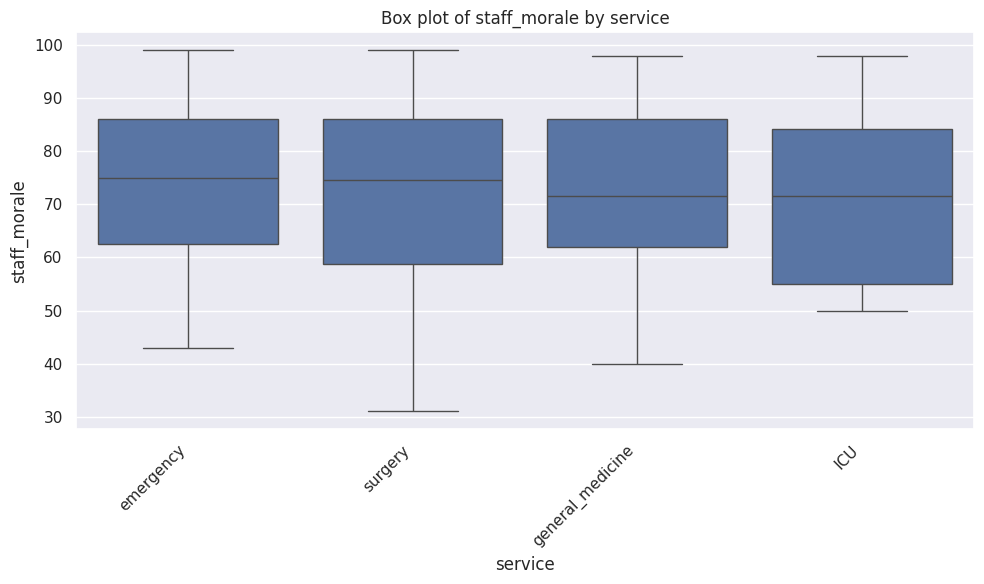

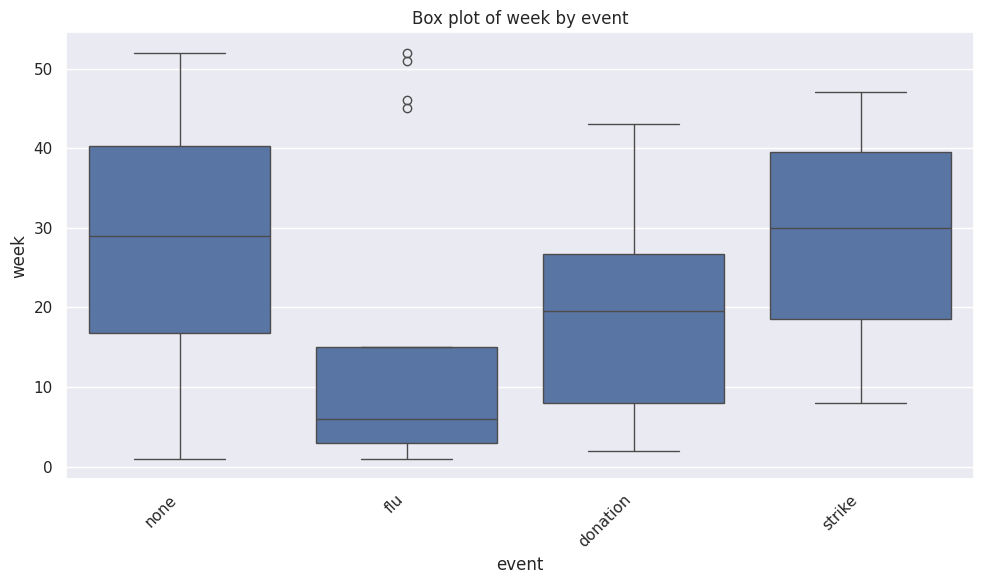

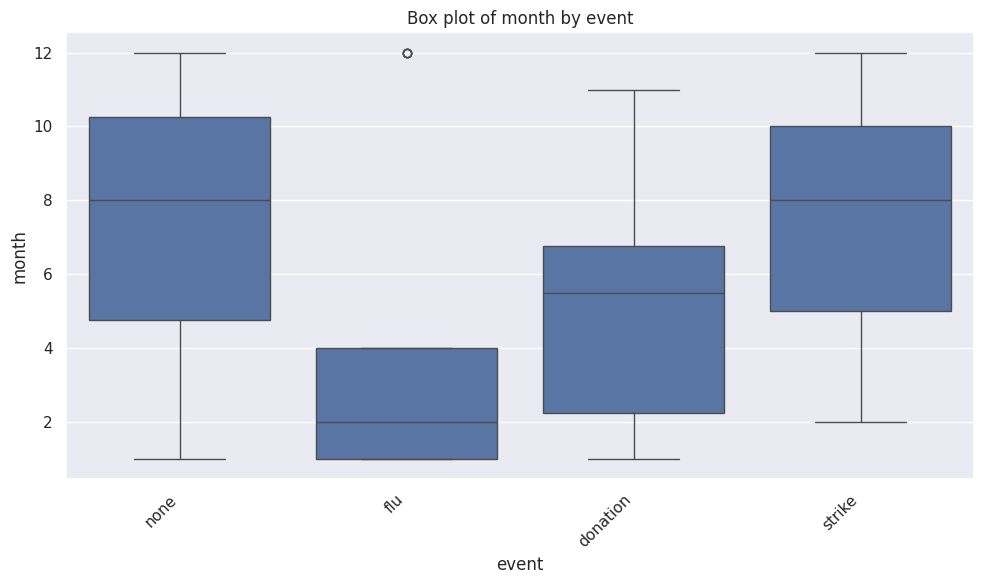

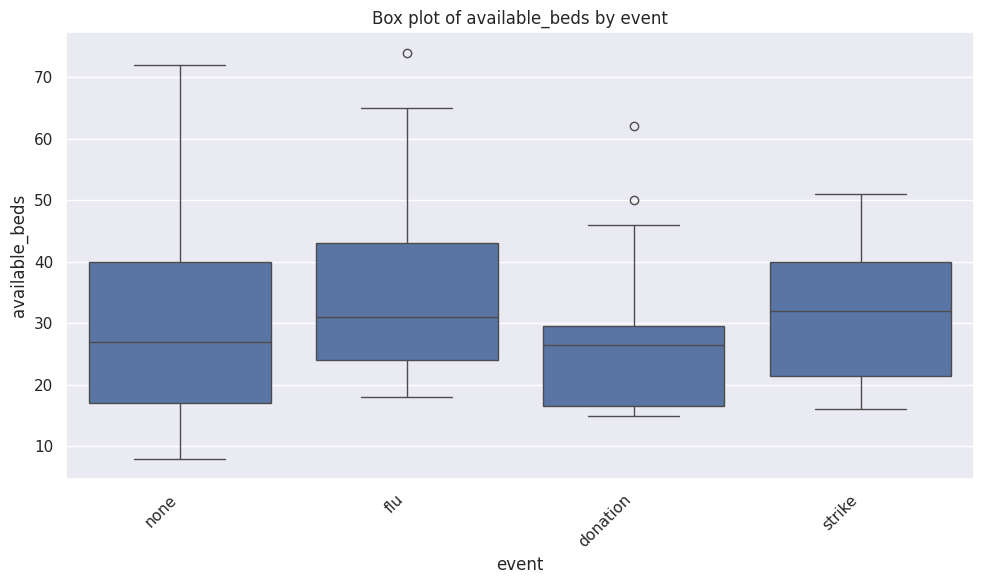

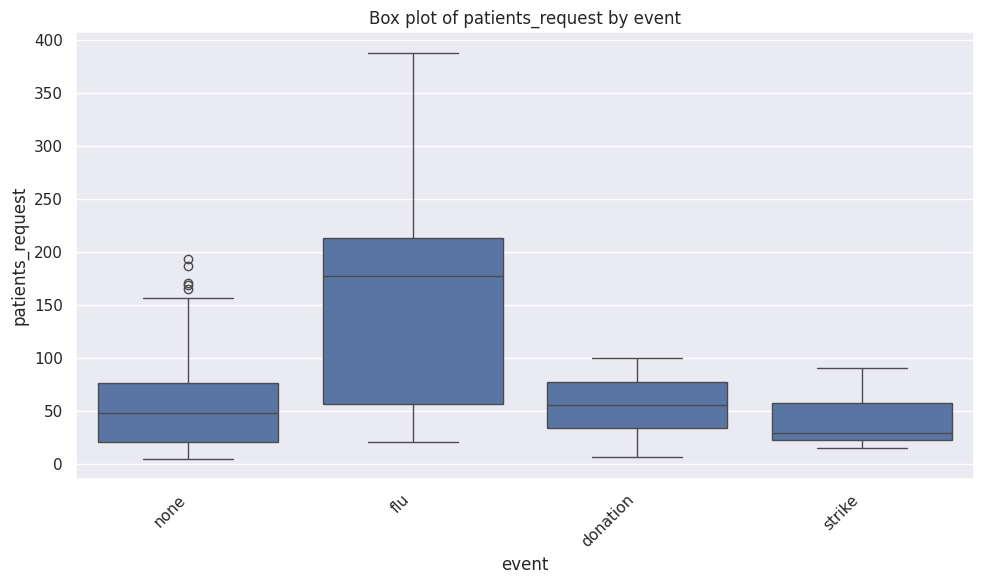

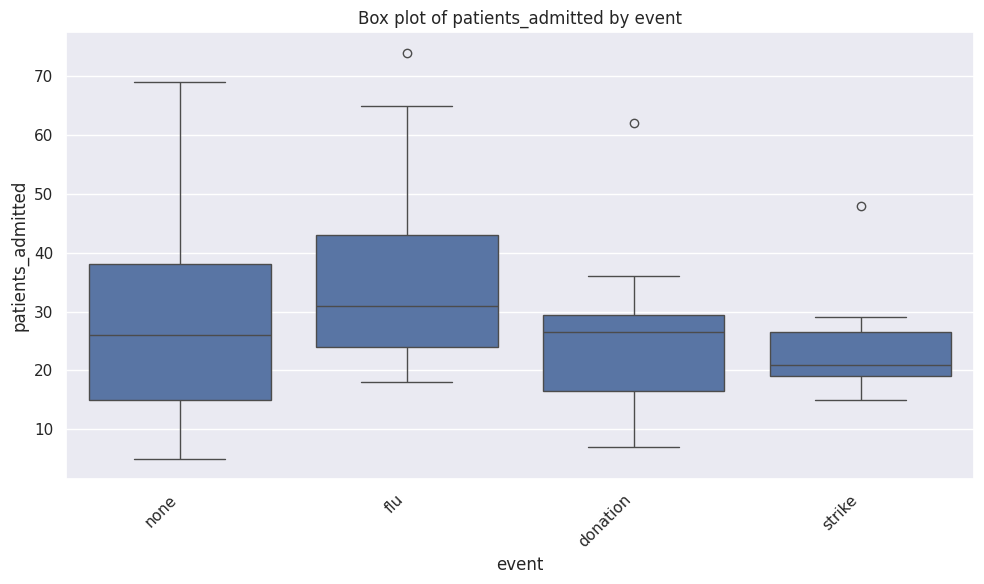

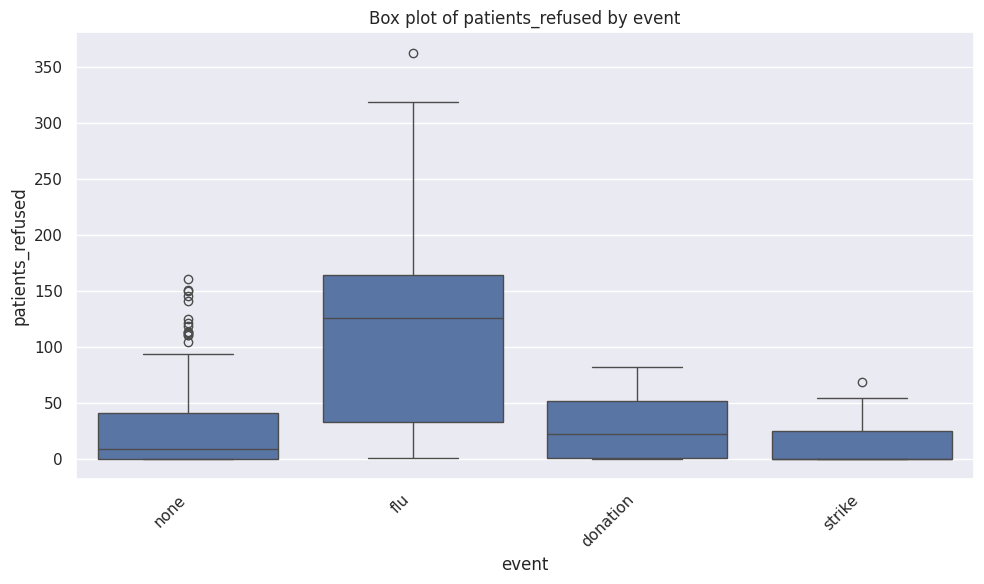

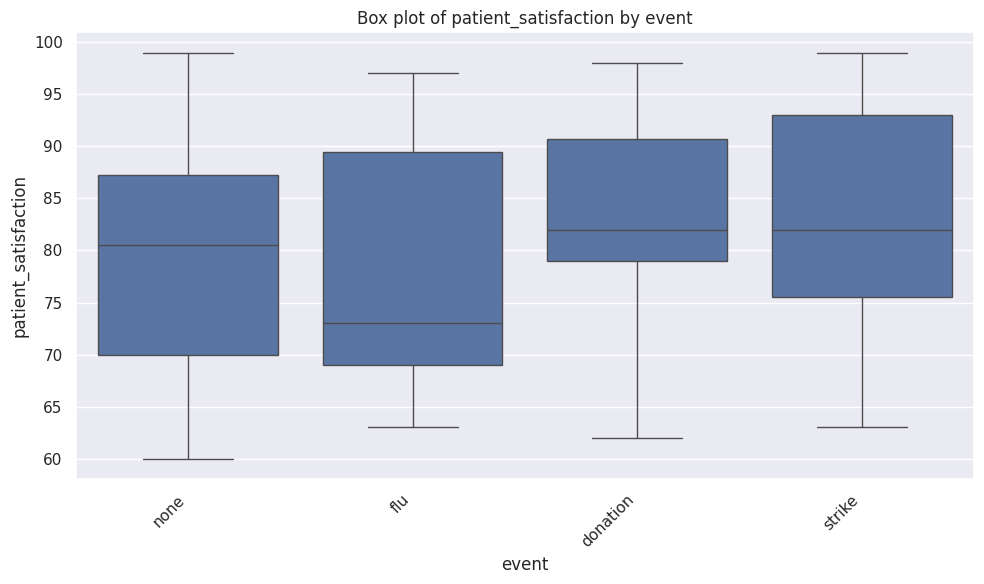

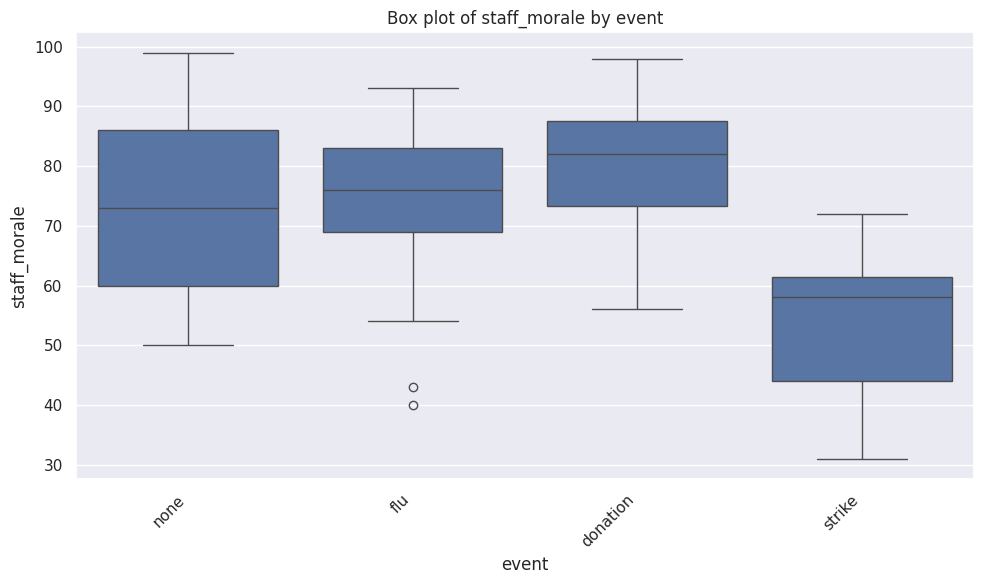

In [27]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

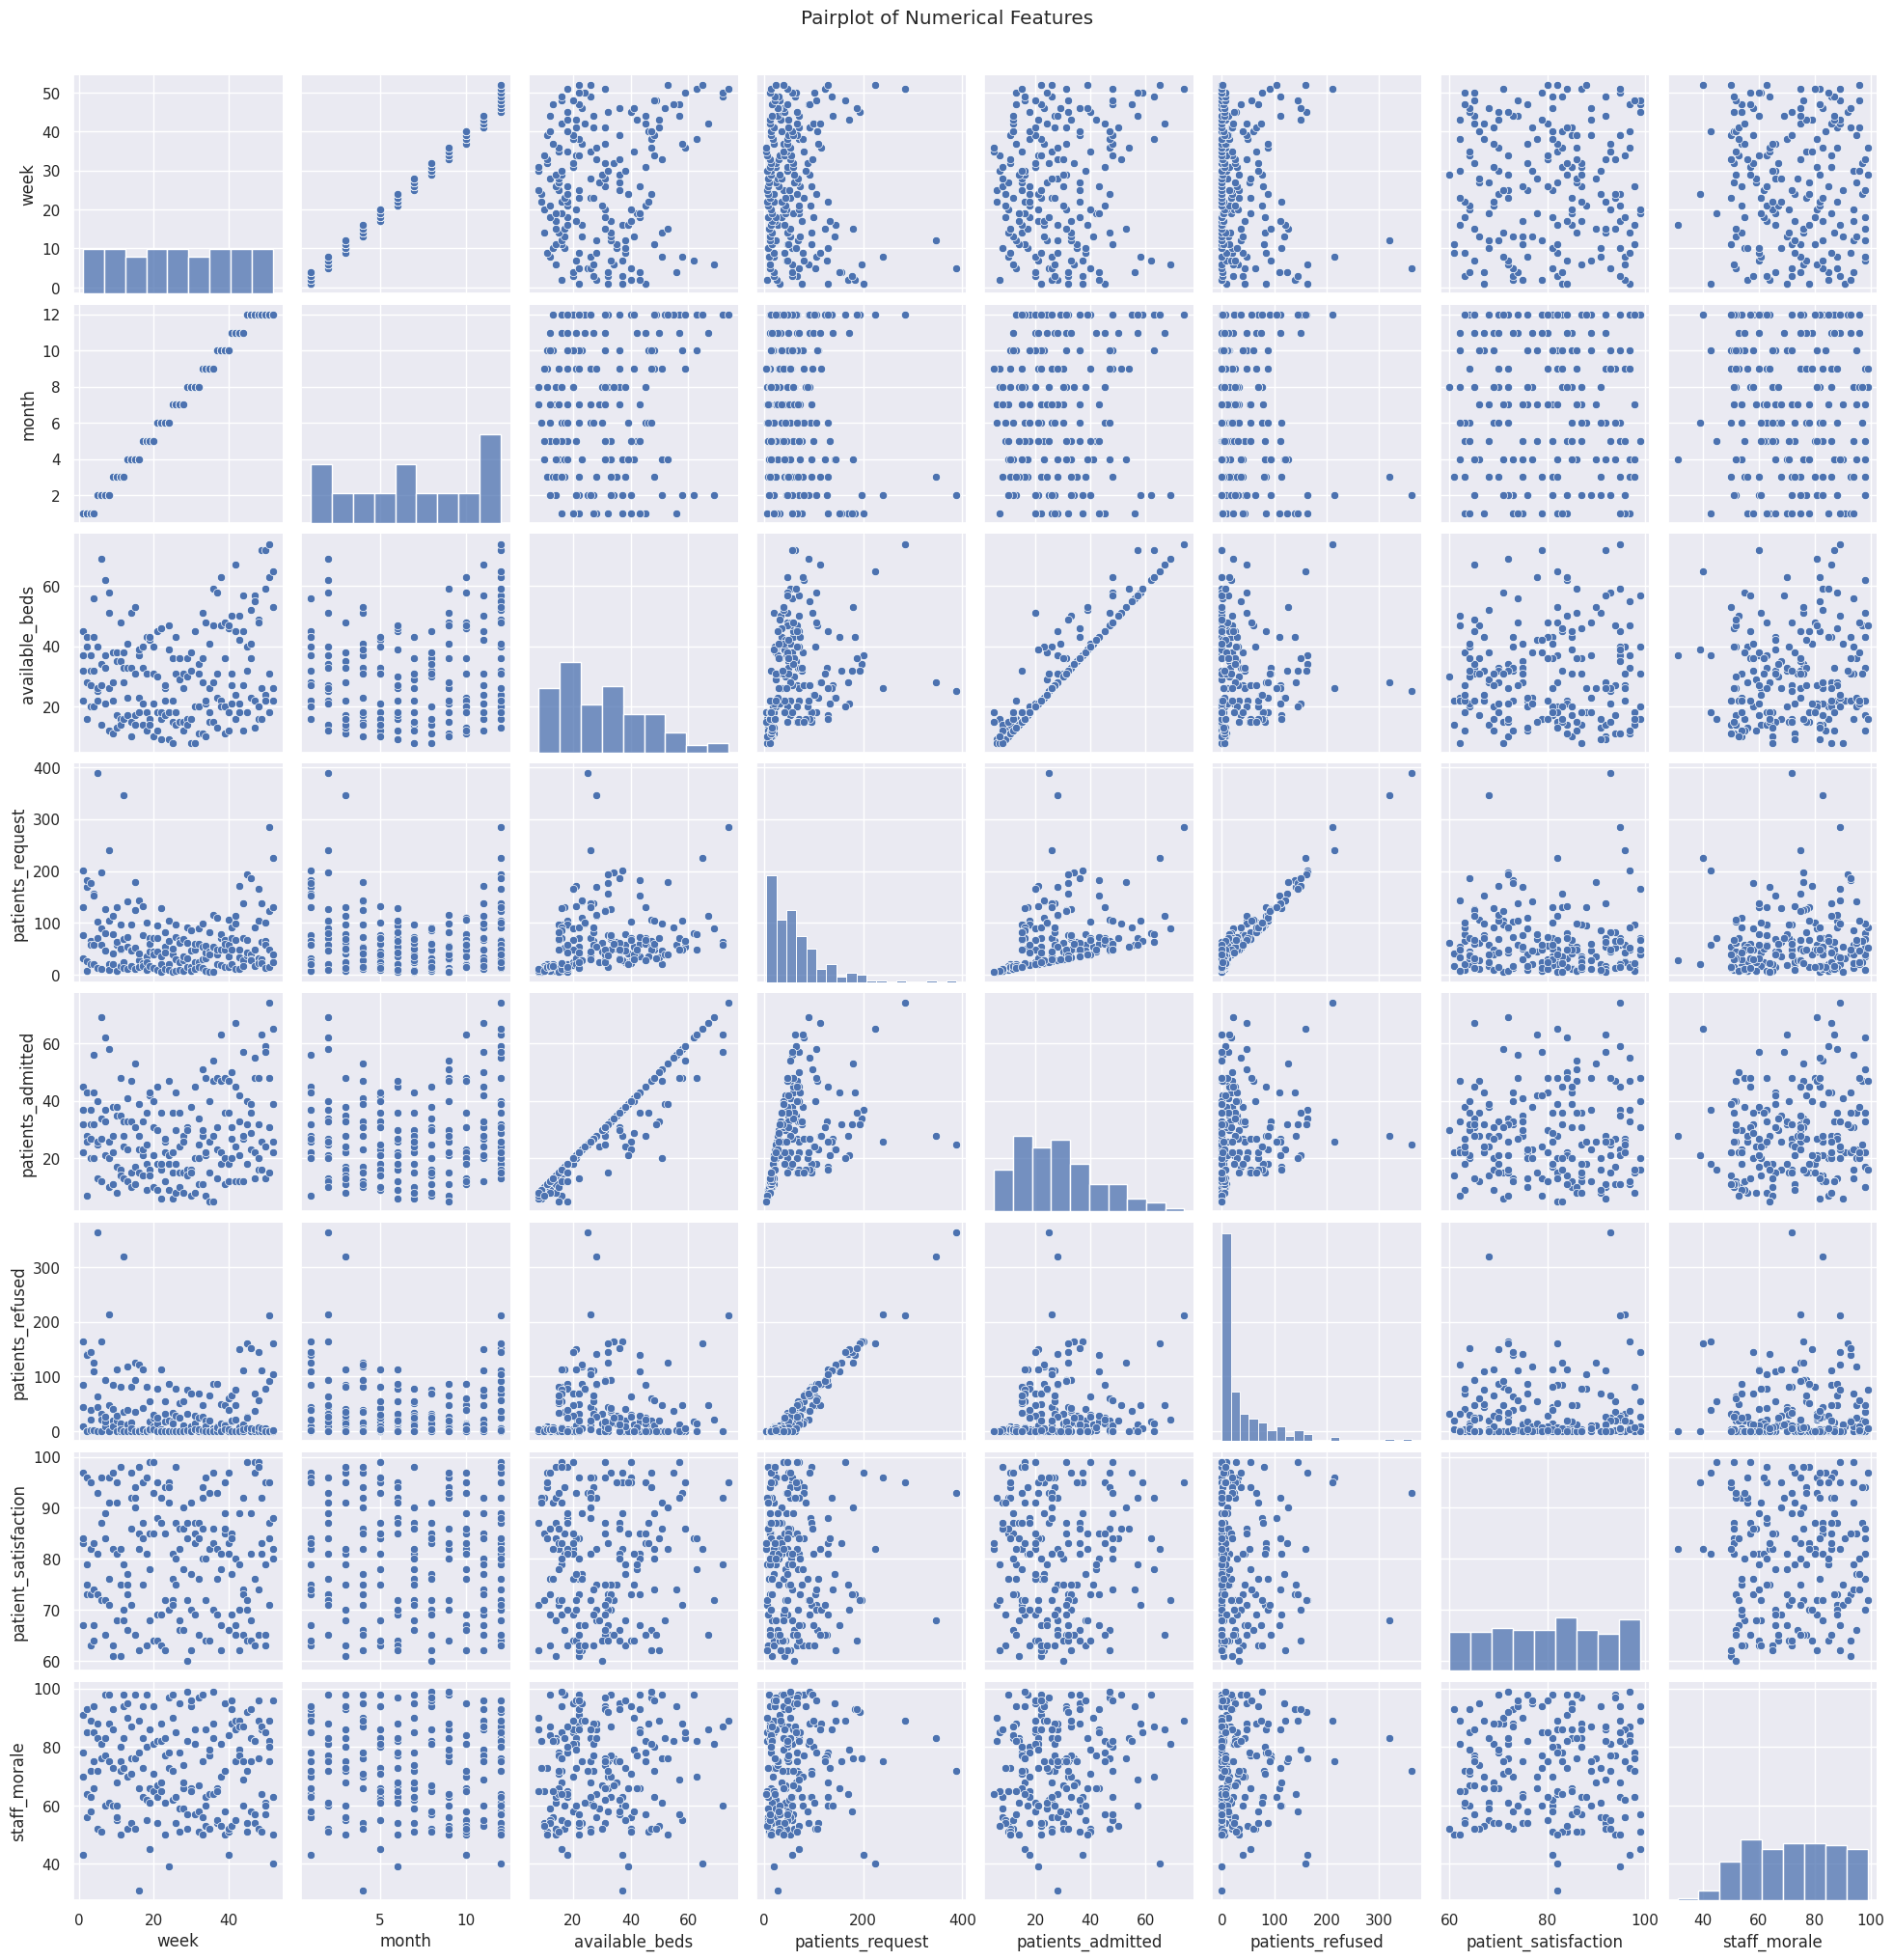

In [28]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

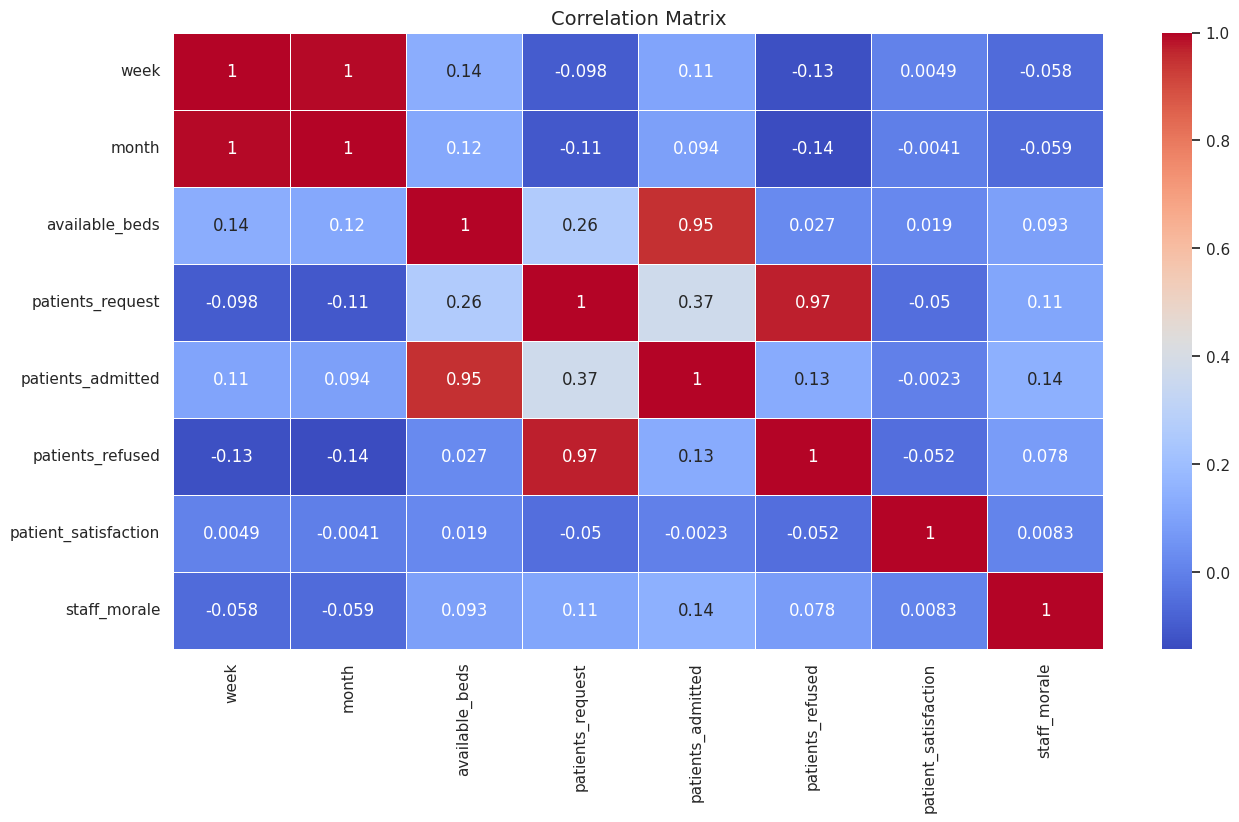

In [29]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you